In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report, log_loss
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import sys
sys.path.append('..')
from scripts.database import cargar_datos

# Configuración
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

os.makedirs("../data/graficas", exist_ok=True)
print("✅ Librerías importadas")

✅ Librerías importadas


In [ ]:
df = cargar_datos()

# Crear target binario
mediana = df['pib_per_capita_usd'].median()
df['pib_alto'] = (df['pib_per_capita_usd'] > mediana).astype(int)

# Características
features = ['pib_usd', 'crecimiento_pib_pct', 'inflacion_pct',  
            'desempleo_pct', 'exportaciones_pct_pib', 'importaciones_pct_pib']

features_existentes = [f for f in features if f in df.columns]

# Limpiar
df_clean = df.dropna(subset=['pib_alto'])
for col in features_existentes:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

X = df_clean[features_existentes]
y = df_clean['pib_alto']

print(f"✅ X: {X.shape}, y: {y.shape}")
print(f"Clase 1: {y.sum()} ({y.mean()*100:.1f}%)")

✅ X: (168, 6), y: (168,)
Clase 1: 84 (50.0%)


In [24]:
def evaluar_split(X, y, test_size, nombre):
    # Split con estratificación
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Resampling (NO SMOTE)
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    
    # Escalar (importante para regresión logística)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test)
    
    # Regresión Logística
    modelo = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    modelo.fit(X_train_scaled, y_train_res)
    
    # Predicciones
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n📊 {nombre}")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  F1: {f1:.4f} | AUC: {auc:.4f}")
    
    # Gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'], ax=axes[0])
    axes[0].set_title(f'Matriz - {nombre}')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, 'b-', label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--')
    axes[1].set_title(f'ROC - {nombre}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f"../data/graficas/logreg_{nombre}.png", dpi=120)
    plt.show()
    
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc}, modelo


📊 80_20
  Accuracy: 0.7941 | Precision: 0.8571 | Recall: 0.7059
  F1: 0.7742 | AUC: 0.7682


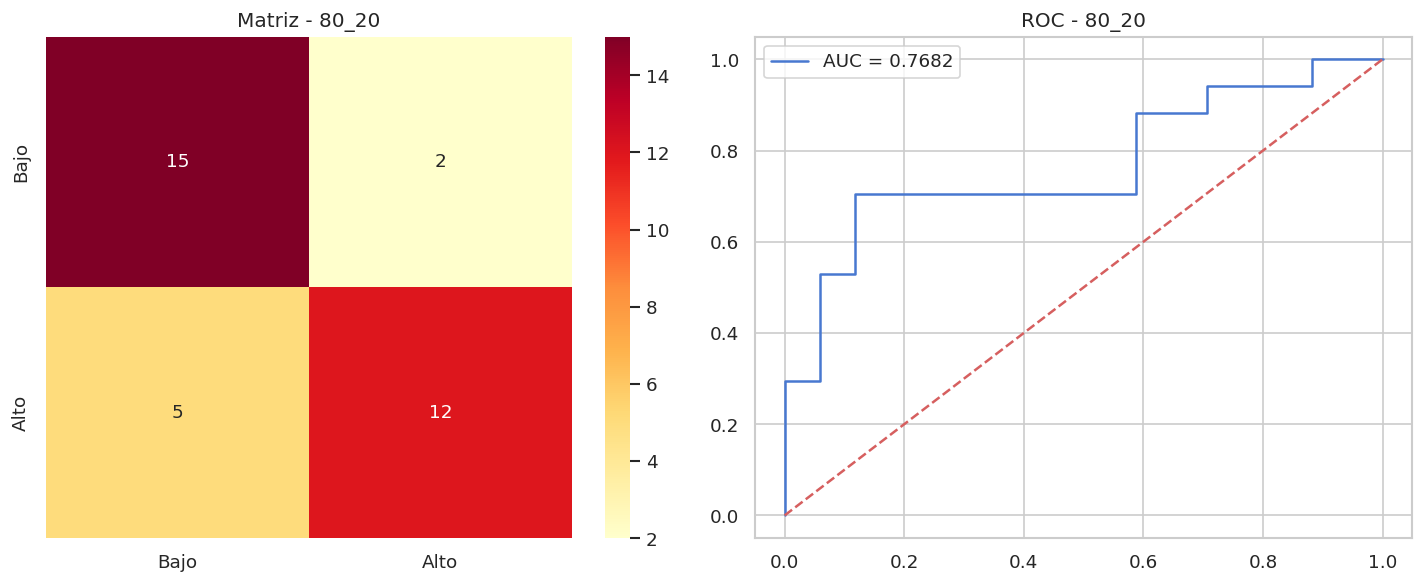


📊 60_40
  Accuracy: 0.6912 | Precision: 0.6757 | Recall: 0.7353
  F1: 0.7042 | AUC: 0.7413


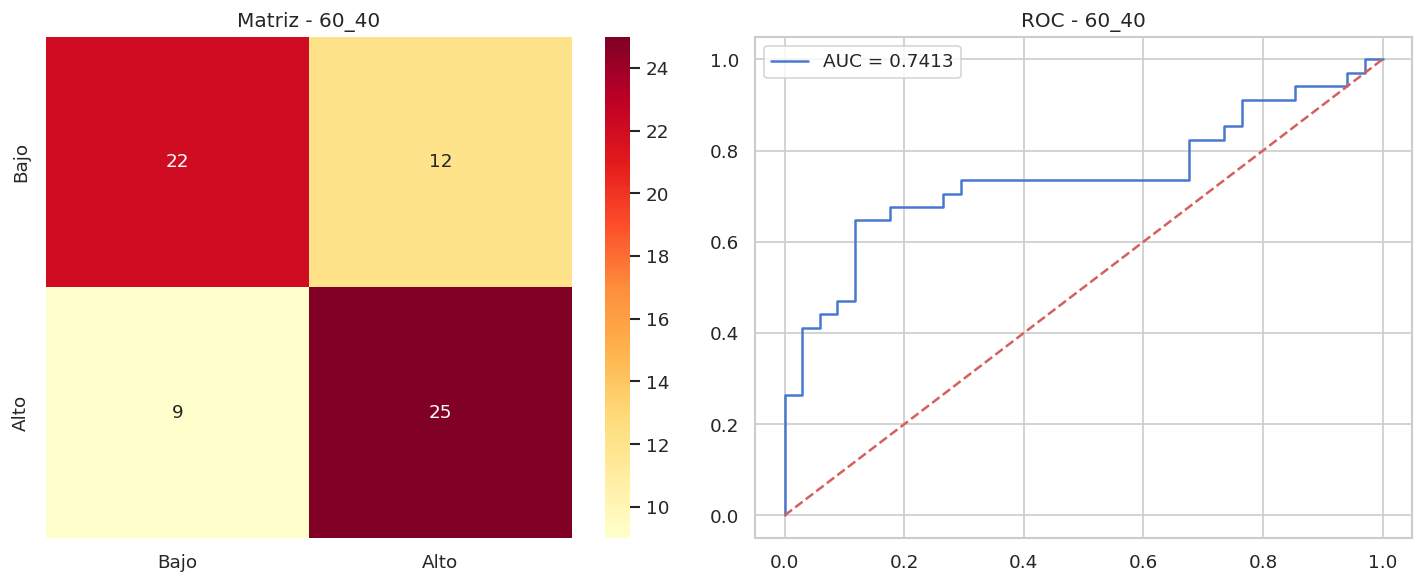


📊 70_30
  Accuracy: 0.7451 | Precision: 0.7500 | Recall: 0.7200
  F1: 0.7347 | AUC: 0.7462


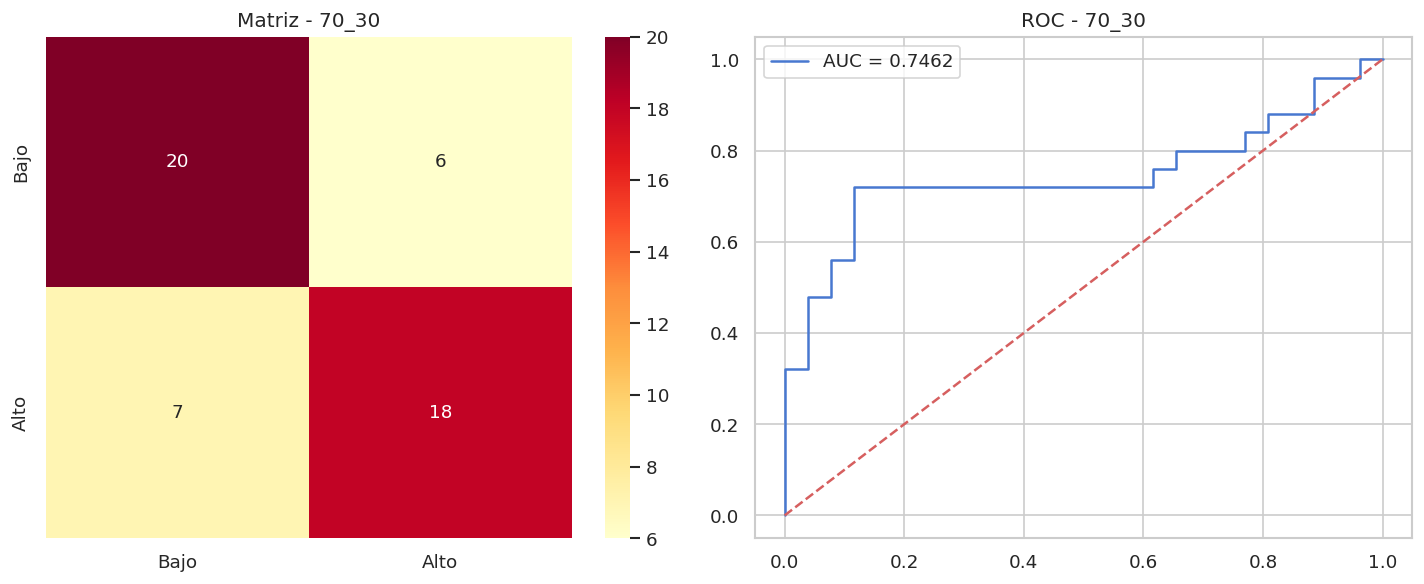

In [25]:
resultados = {}
modelos = {}

for nombre, ts in [('80_20', 0.20), ('60_40', 0.40), ('70_30', 0.30)]:
    res, model = evaluar_split(X, y, ts, nombre)
    resultados[nombre] = res
    modelos[nombre] = model


📊 COMPARATIVA
          acc    prec     rec      f1     auc
80_20  0.7941  0.8571  0.7059  0.7742  0.7682
60_40  0.6912  0.6757  0.7353  0.7042  0.7413
70_30  0.7451  0.7500  0.7200  0.7347  0.7462


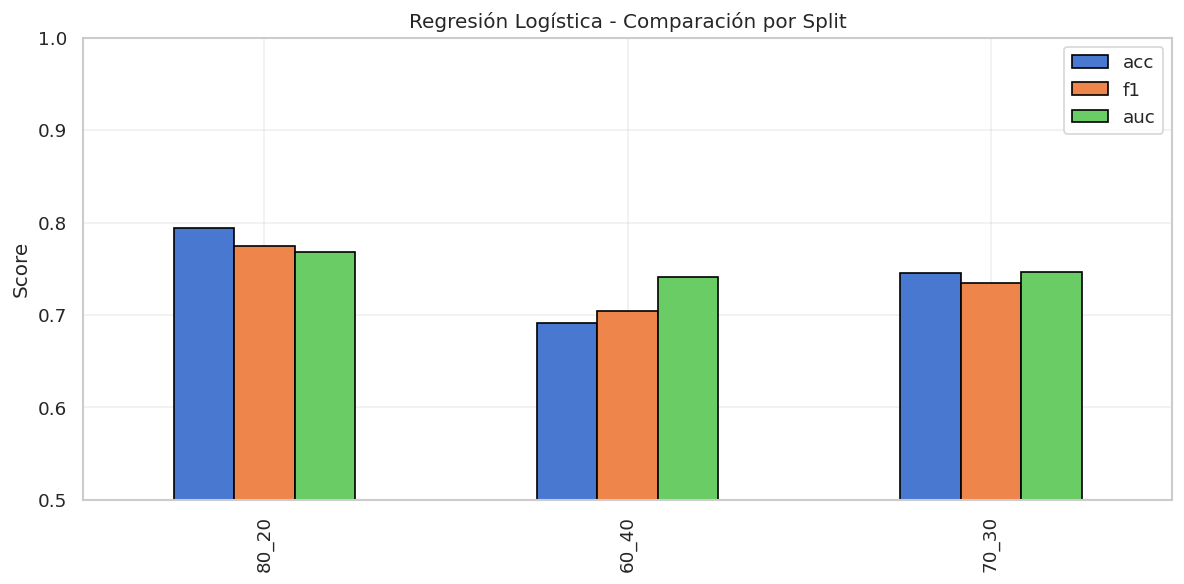

In [26]:
df_res = pd.DataFrame(resultados).T
print("\n📊 COMPARATIVA")
print(df_res.round(4))

df_res[['acc', 'f1', 'auc']].plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Regresión Logística - Comparación por Split')
plt.ylabel('Score')
plt.ylim(0.5, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/graficas/logreg_comparativa.png", dpi=120)
plt.show()

In [12]:
def evaluar_split_logreg(X, y, test_size, nombre):
    # División
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )
    
    # Resampling (NO SMOTE)
    ros = RandomOverSampler(random_state=42)
    X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
    
    # Escalar (IMPORTANTE para Regresión Logística)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_res)
    X_test_scaled = scaler.transform(X_test)
    
    # REGRESIÓN LOGÍSTICA (no es un árbol)
    modelo = LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        C=1.0  # Regularización
    )
    modelo.fit(X_train_scaled, y_train_res)
    
    # Predicciones
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    
    print(f"\n{'='*50}")
    print(f"📊 {nombre} ({(1-test_size)*100:.0f}/{test_size*100:.0f})")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"  Log Loss:  {logloss:.4f}")
    
    # Ecuación del modelo
    intercepto = modelo.intercept_[0]
    print(f"\n  📐 Ecuación: log(p/(1-p)) = {intercepto:.4f}", end="")
    for i, col in enumerate(features_existentes):
        coef = modelo.coef_[0][i]
        signo = "+" if coef >= 0 else "-"
        print(f" {signo} {abs(coef):.4f}·{col}", end="")
    print()
    
    # Gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=['PIB Bajo', 'PIB Alto'],
                yticklabels=['PIB Bajo', 'PIB Alto'], ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - {nombre}')
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--', label='Aleatorio')
    axes[1].set_title(f'Curva ROC - {nombre}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"../data/graficas/logreg_{nombre}_graficas.png", dpi=120)
    plt.show()
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 
        'f1': f1, 'roc_auc': auc, 'log_loss': logloss
    }, modelo, scaler


📊 80_20 (80/20)
  Accuracy:  0.7941
  Precision: 0.8571
  Recall:    0.7059
  F1-Score:  0.7742
  ROC-AUC:   0.7682
  Log Loss:  0.5537

  📐 Ecuación: log(p/(1-p)) = 0.3328 + 1.8972·pib_usd - 0.1477·crecimiento_pib_pct + 0.6001·inflacion_pct - 0.2129·desempleo_pct + 0.1745·exportaciones_pct_pib + 0.4271·importaciones_pct_pib


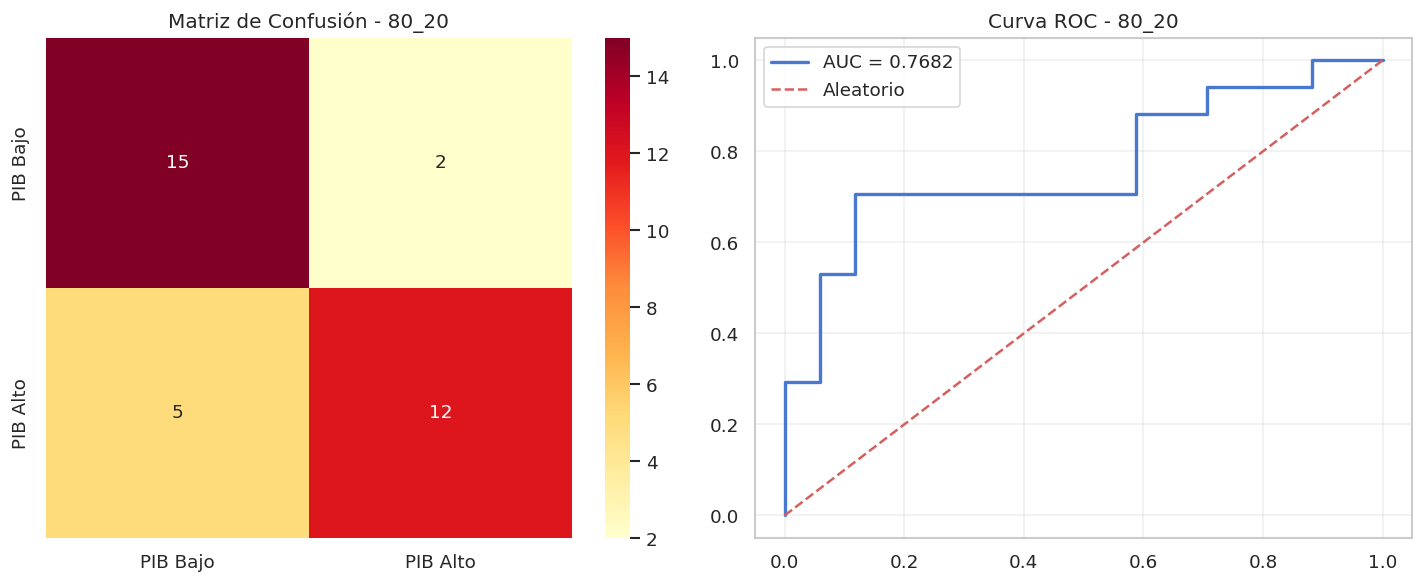

In [13]:
resultados = {}
modelos = {}
scalers = {}

res, model, scaler = evaluar_split_logreg(X, y, test_size=0.20, nombre="80_20")
resultados['80/20'] = res
modelos['80/20'] = model
scalers['80/20'] = scaler


📊 60_40 (60/40)
  Accuracy:  0.6912
  Precision: 0.6757
  Recall:    0.7353
  F1-Score:  0.7042
  ROC-AUC:   0.7413
  Log Loss:  0.5928

  📐 Ecuación: log(p/(1-p)) = 0.2543 + 1.6706·pib_usd - 0.2070·crecimiento_pib_pct + 0.5269·inflacion_pct - 0.3713·desempleo_pct + 0.0816·exportaciones_pct_pib + 0.6025·importaciones_pct_pib


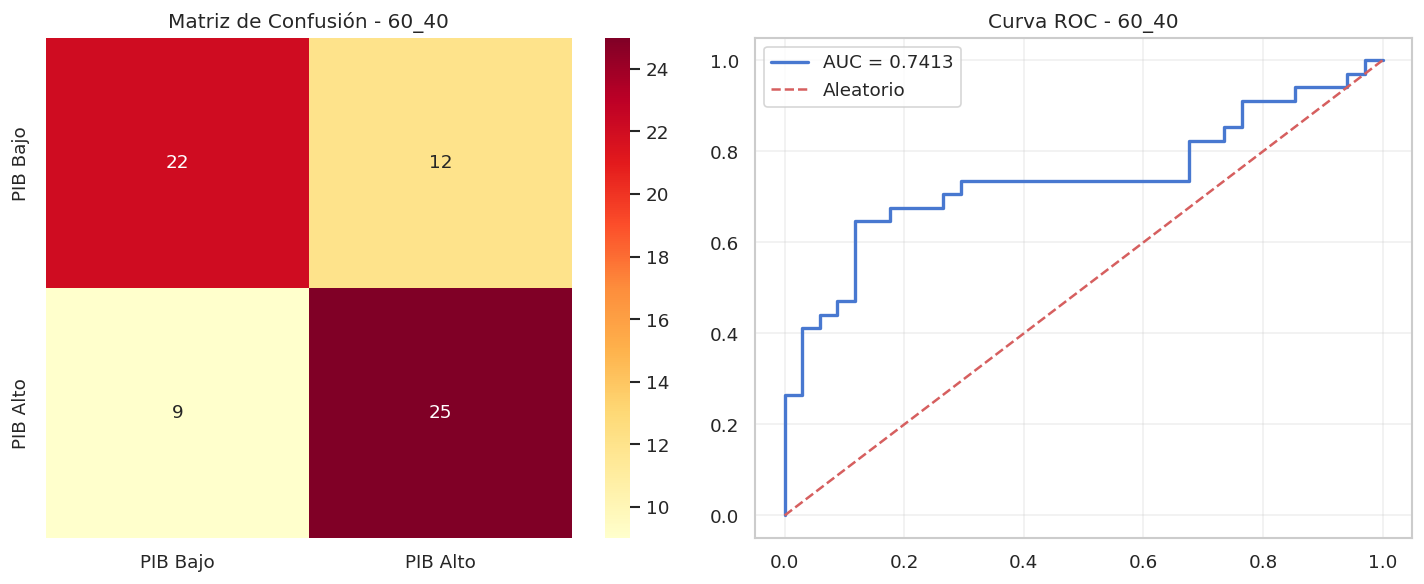

In [14]:
res, model, scaler = evaluar_split_logreg(X, y, test_size=0.40, nombre="60_40")
resultados['60/40'] = res
modelos['60/40'] = model
scalers['60/40'] = scaler


📊 70_30 (70/30)
  Accuracy:  0.7451
  Precision: 0.7500
  Recall:    0.7200
  F1-Score:  0.7347
  ROC-AUC:   0.7462
  Log Loss:  0.5701

  📐 Ecuación: log(p/(1-p)) = 0.2703 + 1.7430·pib_usd - 0.3275·crecimiento_pib_pct + 0.4005·inflacion_pct - 0.1786·desempleo_pct + 0.1700·exportaciones_pct_pib + 0.5210·importaciones_pct_pib


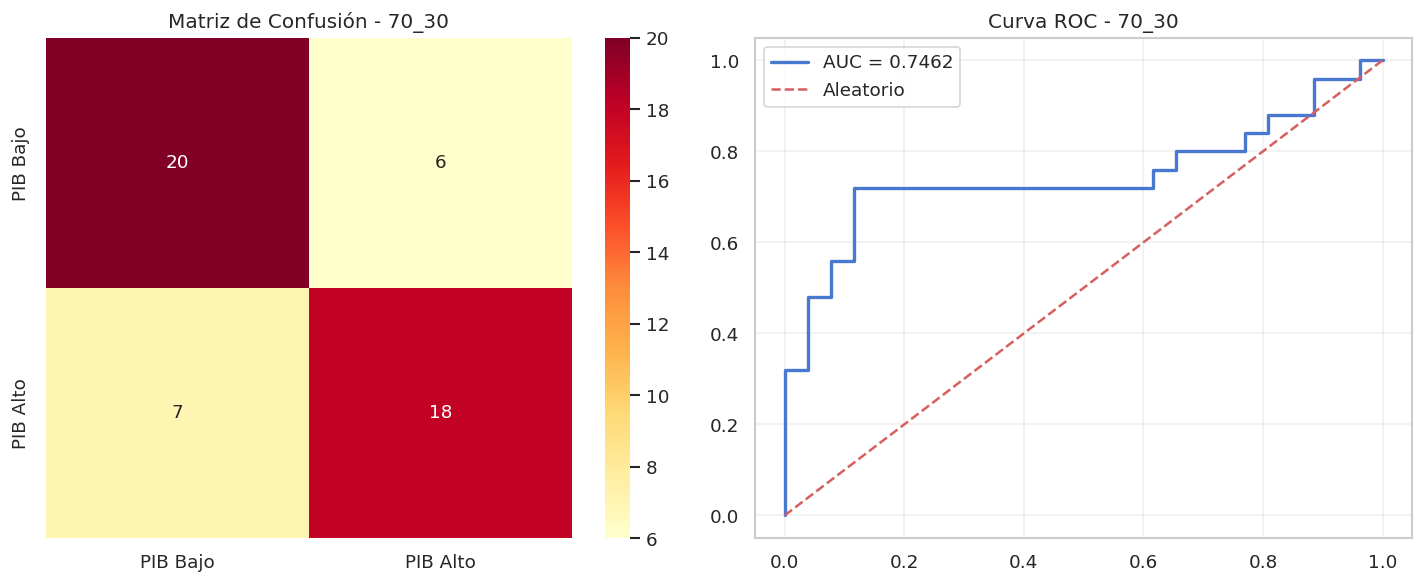

In [15]:
res, model, scaler = evaluar_split_logreg(X, y, test_size=0.30, nombre="70_30")
resultados['70/30'] = res
modelos['70/30'] = model
scalers['70/30'] = scaler


📊 TABLA COMPARATIVA
       accuracy  precision  recall      f1  roc_auc  log_loss
80/20    0.7941     0.8571  0.7059  0.7742   0.7682    0.5537
60/40    0.6912     0.6757  0.7353  0.7042   0.7413    0.5928
70/30    0.7451     0.7500  0.7200  0.7347   0.7462    0.5701

📈 Estabilidad F1: ±0.03508


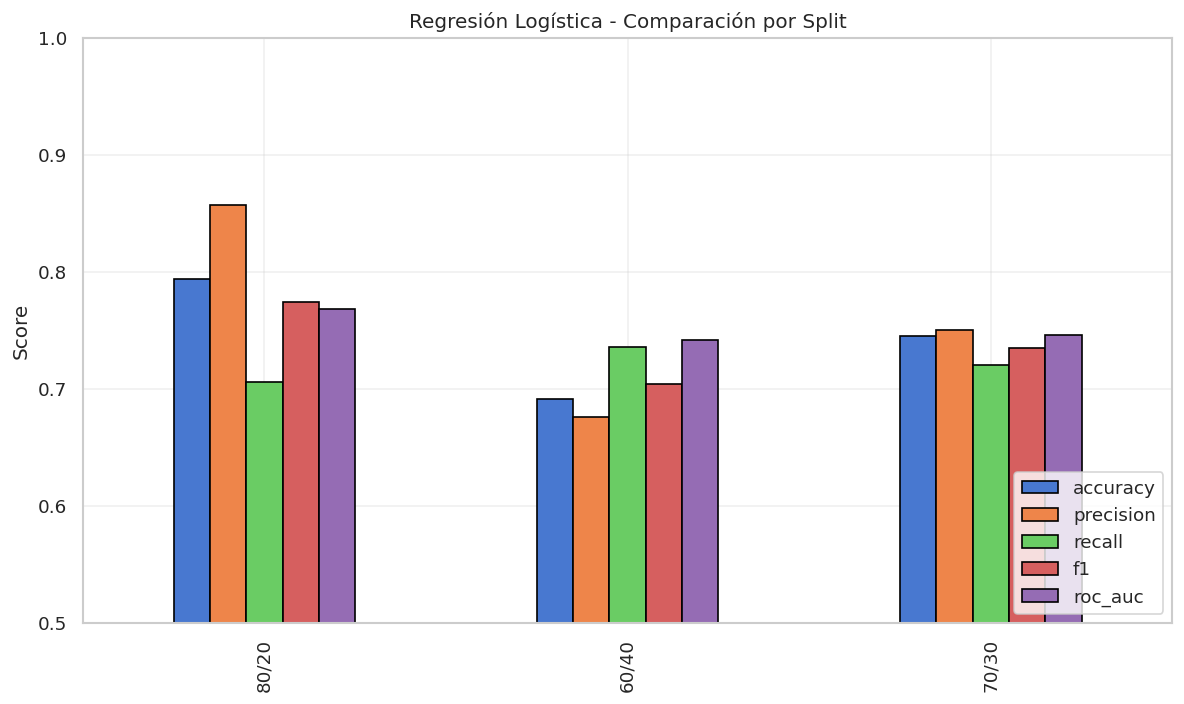

In [16]:
df_res = pd.DataFrame(resultados).T
print("\n📊 TABLA COMPARATIVA")
print("="*60)
print(df_res.round(4))
print(f"\n📈 Estabilidad F1: ±{df_res['f1'].std():.5f}")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
df_res[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(
    kind='bar', ax=ax, edgecolor='black'
)
ax.set_title('Regresión Logística - Comparación por Split')
ax.set_ylabel('Score')
ax.set_ylim([0.5, 1])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/graficas/logreg_comparativa.png", dpi=120)
plt.show()

📊 COEFICIENTES
(Positivo → aumenta probabilidad de PIB alto)
  ⬆️ pib_usd                        → +1.8972
  ⬆️ inflacion_pct                  → +0.6001
  ⬆️ importaciones_pct_pib          → +0.4271
  ⬆️ exportaciones_pct_pib          → +0.1745
  ⬇️ crecimiento_pib_pct            → -0.1477
  ⬇️ desempleo_pct                  → -0.2129


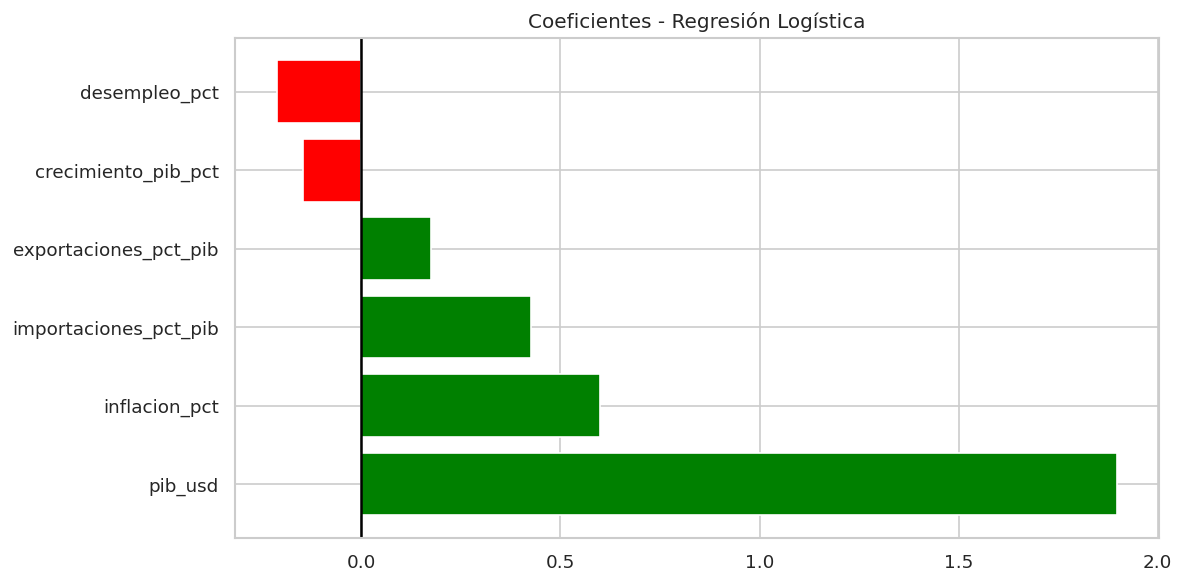

In [28]:
modelo = modelos['80_20']
coef_df = pd.DataFrame({
    'Variable': features_existentes,
    'Coeficiente': modelo.coef_[0],
    'Impacto': np.exp(modelo.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("📊 COEFICIENTES")
print("(Positivo → aumenta probabilidad de PIB alto)")
for _, row in coef_df.iterrows():
    flecha = "⬆️" if row['Coeficiente'] > 0 else "⬇️"
    print(f"  {flecha} {row['Variable']:<30} → {row['Coeficiente']:+.4f}")

# Gráfico
plt.figure(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors)
plt.axvline(x=0, color='black')
plt.title('Coeficientes - Regresión Logística')
plt.tight_layout()
plt.savefig("../data/graficas/logreg_coeficientes.png", dpi=120)
plt.show()

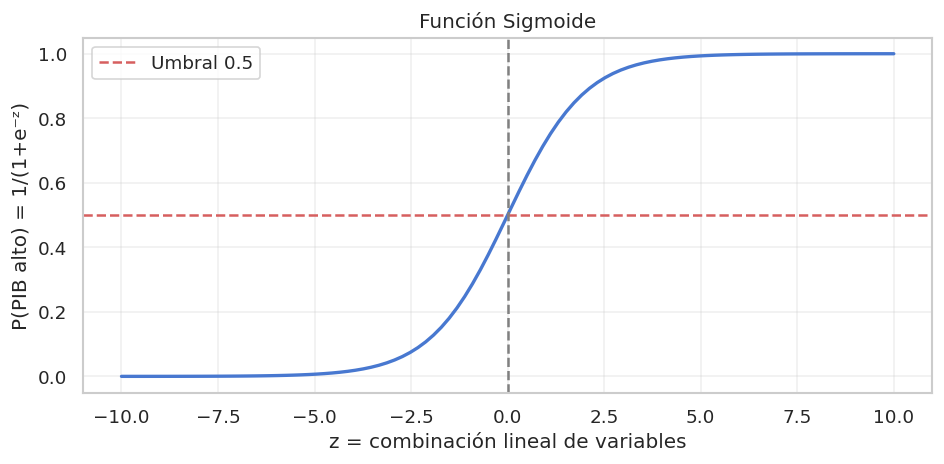

In [29]:
z = np.linspace(-10, 10, 100)
sigmoide = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoide, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Umbral 0.5')
plt.axvline(x=0, color='gray', linestyle='--')
plt.xlabel('z = combinación lineal de variables')
plt.ylabel('P(PIB alto) = 1/(1+e⁻ᶻ)')
plt.title('Función Sigmoide')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/graficas/logreg_sigmoide.png", dpi=120)
plt.show()

In [30]:
print("\n" + "="*50)
print("📝 CONCLUSIONES - REGRESIÓN LOGÍSTICA")
print("="*50)

mejor_f1 = max([r['f1'] for r in resultados.values()])

print(f"""
✅ RENDIMIENTO: F1-Score = {mejor_f1:.4f} ({mejor_f1*100:.1f}%)

✅ CARACTERÍSTICA ÚNICA:
   • Coeficiente más importante: {coef_df.iloc[0]['Variable']}
   • Coeficiente: {coef_df.iloc[0]['Coeficiente']:+.4f}

✅ DIFERENCIA CON ÁRBOL:
   • Árbol: reglas if-else, frontera en escalones
   • Logística: ecuación lineal + sigmoide, coeficientes interpretables

✅ RESTRICCIONES:
   • Sin ensembles ✓ | Sin SMOTE ✓ | Con resampling ✓

📁 Gráficas: ../data/graficas/logreg_*.png
""")

print("="*50)
print("✅ NOTEBOOK COMPLETADO")


📝 CONCLUSIONES - REGRESIÓN LOGÍSTICA

✅ RENDIMIENTO: F1-Score = 0.7742 (77.4%)

✅ CARACTERÍSTICA ÚNICA:
   • Coeficiente más importante: pib_usd
   • Coeficiente: +1.8972

✅ DIFERENCIA CON ÁRBOL:
   • Árbol: reglas if-else, frontera en escalones
   • Logística: ecuación lineal + sigmoide, coeficientes interpretables

✅ RESTRICCIONES:
   • Sin ensembles ✓ | Sin SMOTE ✓ | Con resampling ✓

📁 Gráficas: ../data/graficas/logreg_*.png

✅ NOTEBOOK COMPLETADO
